# Phase 4: Supervised Learning - Predicting Clinic Visit Demand

**Project:** UniMediTrend - AI-Based Analysis and Prediction of Student Clinic Visits  
**Goal:** Train regression models to forecast weekly clinic visit volume, broken down by hostel risk tier (from Phase 3 clustering).  
**Models:** Linear Regression (baseline) + Random Forest Regressor (primary)  
**Evaluation:** MAE, RMSE, R², 5-Fold Cross-Validation

## 1. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import joblib
import os

from pymongo import MongoClient
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# === Plot style (matches EDA notebook) ===
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d2e',
    'axes.edgecolor':   '#2d3148',
    'axes.labelcolor':  '#9ca3af',
    'xtick.color':      '#6b7280',
    'ytick.color':      '#6b7280',
    'text.color':       '#e5e7eb',
    'grid.color':       '#2d3148',
    'grid.linestyle':   '--',
    'grid.alpha':        0.5,
    'font.family':      'serif',
})
TEAL   = '#00c9a7'
BLUE   = '#0072ff'
AMBER  = '#f59e0b'
RED    = '#ff6b6b'
PURPLE = '#a78bfa'
PALETTE = [TEAL, BLUE, AMBER, RED, PURPLE, '#fb923c', '#6ee7b7']

# === Output folder for saved models ===
os.makedirs('models', exist_ok=True)
print(' All libraries loaded.')

 All libraries loaded.


## 2. Load Enriched Data from MongoDB

We load from `clinic_logs_enriched` - the collection produced in Phase 3 that already contains the `hostel_risk_tier` and `visit_archetype` cluster labels.

In [2]:
# === Connect to MongoDB ===
client = MongoClient('mongodb://localhost:27017/')

DB_NAME = 'UniMediTrend'
db = client[DB_NAME]

# Load the Phase 3 enriched collection
collection = db['clinic_logs_enriched']
raw_docs = list(collection.find({}, {'_id': 0}))

df = pd.DataFrame(raw_docs)
print(f'   Loaded {len(df):,} records from "{DB_NAME}.clinic_logs_enriched"')
print(f'   Columns: {list(df.columns)}')

   Loaded 5,799 records from "UniMediTrend.clinic_logs_enriched"
   Columns: ['visit_date', 'level', 'gender', 'department', 'hostel', 'diagnosis', 'severity', 'month', 'month_sin', 'month_cos', 'hostel_risk_cluster', 'visit_cluster_label']


## 3. Data Preparation & Time-Series Rollup

ML regression models need structured numeric rows, not individual patient records.  
We **aggregate** the raw visit logs into a **weekly time series**, counting:
- Total visits per week
- Visits from each hostel risk tier (High Risk, Medium Risk, Wellness Risk)

This directly supports the operational goal: *"How many patients, and of what type, should we expect to visit next week?"*

In [3]:
# === Parse visit_date ===
df['visit_date'] = pd.to_datetime(df['visit_date'])

# === Add time index columns ===
df['week'] = df['visit_date'].dt.isocalendar().week.astype(int)
df['year'] = df['visit_date'].dt.isocalendar().year.astype(int)
df['month'] = df['visit_date'].dt.month

# === Identify risk tier column ===
TIER_COL = 'hostel_risk_cluster'

if TIER_COL not in df.columns:
    raise KeyError(f'Column "{TIER_COL}" not found. Available: {list(df.columns)}')

# === Weekly rollup: total visits per week ===
weekly_total = (
    df.groupby(['year', 'week'])
      .size()
      .reset_index(name='total_visits')
)

# === Weekly rollup: visits per risk tier ===
tier_counts = (
    df.groupby(['year', 'week', TIER_COL])
      .size()
      .unstack(fill_value=0)
      .reset_index()
)

# Clean column names produced by unstack
tier_counts.columns.name = None
tier_cols_renamed = {
    col: f'visits_{col.lower().replace(" ", "_")}'
    for col in tier_counts.columns
    if col not in ['year', 'week']
}
tier_counts.rename(columns=tier_cols_renamed, inplace=True)

# === Merge into single weekly dataframe ===
weekly = weekly_total.merge(tier_counts, on=['year', 'week'])

# === Sort chronologically ===
weekly = weekly.sort_values(['year', 'week']).reset_index(drop=True)

# === Add representative month per week (for cyclical encoding) ===
week_month_map = (
    df.groupby(['year', 'week'])['month']
      .agg(lambda x: x.mode()[0])
      .reset_index()
)
weekly = weekly.merge(week_month_map, on=['year', 'week'])

print(f' Weekly time-series shape: {weekly.shape}')
print(f'   Spanning {weekly.shape[0]} weeks')
weekly.head(8)

 Weekly time-series shape: (114, 7)
   Spanning 114 weeks


,year,week,total_visits,visits_academic_burnout_zone,visits_food/water-borne_zone,visits_high-acuity_/_malaria_risk,month
0,2024,3,48,26,12,10,1
1,2024,4,44,13,20,11,1
2,2024,5,47,13,17,17,2
3,2024,6,54,17,22,15,2
4,2024,7,49,17,21,11,2
5,2024,8,50,15,17,18,2
6,2024,9,50,20,18,12,2
7,2024,10,48,14,20,14,3


## 4. Feature Engineering

We build **lag features** and **cyclical time encodings** — the two most important feature groups for time-series forecasting with sklearn.

| Feature | Rationale |
|---|---|
| `lag_1`, `lag_2`, `lag_3` | Last 1–3 weeks' visits; the strongest predictor of next week |
| `rolling_mean_4` | 4-week rolling average; smooths out noise |
| `month_sin`, `month_cos` | Cyclical encoding; lets the model understand the academic calendar |
| `week_of_year_sin/cos` | Captures within-semester periodicity |

In [4]:
# === Lag features on total_visits ===
weekly['lag_1'] = weekly['total_visits'].shift(1)
weekly['lag_2'] = weekly['total_visits'].shift(2)
weekly['lag_3'] = weekly['total_visits'].shift(3)
weekly['rolling_mean_4'] = weekly['total_visits'].shift(1).rolling(4).mean()

# === Cyclical time encodings ===
weekly['month_sin'] = np.sin(2 * np.pi * weekly['month'] / 12)
weekly['month_cos'] = np.cos(2 * np.pi * weekly['month'] / 12)
weekly['week_sin']  = np.sin(2 * np.pi * weekly['week']  / 52)
weekly['week_cos']  = np.cos(2 * np.pi * weekly['week']  / 52)

# === Drop rows with NaN from lag creation ====
weekly_model = weekly.dropna().reset_index(drop=True)
print(f' Feature-engineered dataset: {weekly_model.shape[0]} usable weeks')

weekly_model[['year','week','total_visits','lag_1','lag_2','rolling_mean_4',
              'month_sin','month_cos']].head(6)

 Feature-engineered dataset: 110 usable weeks


,year,week,total_visits,lag_1,lag_2,rolling_mean_4,month_sin,month_cos
0,2024,7,49,54.0,47.0,48.25,0.866025,5.000000e-01
1,2024,8,50,49.0,54.0,48.50,0.866025,5.000000e-01
2,2024,9,50,50.0,49.0,50.00,0.866025,5.000000e-01
3,2024,10,48,50.0,50.0,50.75,1.000000,6.123234e-17
4,2024,11,52,48.0,50.0,49.25,1.000000,6.123234e-17
5,2024,12,36,52.0,48.0,50.00,1.000000,6.123234e-17


## 5. Train / Test Split

For time-series data we **must not shuffle** - future data cannot be used to predict the past.  
We use an 80/20 chronological split.

In [5]:
# === Define feature columns ===
tier_visit_cols = [c for c in weekly_model.columns if c.startswith('visits_')]

# REMOVED tier_visit_cols from the feature list
FEATURE_COLS = [
    'lag_1', 'lag_2', 'lag_3', 'rolling_mean_4',
    'month_sin', 'month_cos', 'week_sin', 'week_cos'
]

TARGET_COL = 'total_visits'

X = weekly_model[FEATURE_COLS]
y = weekly_model[TARGET_COL]

# === Chronological 80/20 split ===
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f' Training weeks : {len(X_train)}')
print(f' Testing  weeks : {len(X_test)}')
print(f' Features used  : {FEATURE_COLS}')

 Training weeks : 88
 Testing  weeks : 22
 Features used  : ['lag_1', 'lag_2', 'lag_3', 'rolling_mean_4', 'month_sin', 'month_cos', 'week_sin', 'week_cos']


## 6. Model Training

We train two models:
- **Linear Regression** - interpretable baseline, shows whether the relationship is roughly linear
- **Random Forest Regressor** - primary model; handles non-linear patterns like flu spikes and exam-period surges

In [6]:
# === 6a. Linear Regression (Baseline) ===
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

print('=== Linear Regression ==================')
print(f'  MAE  : {mean_absolute_error(y_test, y_pred_lr):.2f} visits')
print(f'  RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.2f} visits')
print(f'  R²   : {r2_score(y_test, y_pred_lr):.4f}')

# === 6b. Random Forest Regressor (Primary) ===
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=4,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)   # RF does not need scaling
y_pred_rf = rf.predict(X_test)

print('\n=== Random Forest Regressor ==============')
print(f'  MAE  : {mean_absolute_error(y_test, y_pred_rf):.2f} visits')
print(f'  RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.2f} visits')
print(f'  R²   : {r2_score(y_test, y_pred_rf):.4f}')

=== Linear Regression ==================
  MAE  : 16.69 visits
  RMSE : 19.46 visits
  R²   : 0.0741

=== Random Forest Regressor ==============
  MAE  : 16.93 visits
  RMSE : 20.90 visits
  R²   : -0.0689


## 7. Cross-Validation (5-Fold)

To ensure our Random Forest results are stable and not just lucky on one test window, we run 5-fold cross-validation on the full dataset.

In [7]:
# TimeSeriesSplit strictly respectimg chronological order
tscv = TimeSeriesSplit(n_splits=5)

cv_mae  = cross_val_score(rf, X, y, cv=tscv, scoring='neg_mean_absolute_error')
cv_rmse = cross_val_score(rf, X, y, cv=tscv, scoring='neg_root_mean_squared_error')
cv_r2   = cross_val_score(rf, X, y, cv=tscv, scoring='r2')

print('=== 5-Fold Time-Series Cross-Validation: Random Forest ===')
print(f'  MAE  per fold : {(-cv_mae).round(2)}')
print(f'  Mean MAE      : {(-cv_mae).mean():.2f} ± {(-cv_mae).std():.2f} visits')
print(f'  Mean RMSE     : {(-cv_rmse).mean():.2f} ± {(-cv_rmse).std():.2f} visits')
print(f'  Mean R²       : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}')

=== 5-Fold Time-Series Cross-Validation: Random Forest ===
  MAE  per fold : [ 9.15  9.13 13.04  8.52 19.64]
  Mean MAE      : 11.90 ± 4.19 visits
  Mean RMSE     : 14.69 ± 4.59 visits
  Mean R²       : -0.0477 ± 0.6314


## 8. Visualisations

### 8a. Actual vs. Predicted Weekly Visits

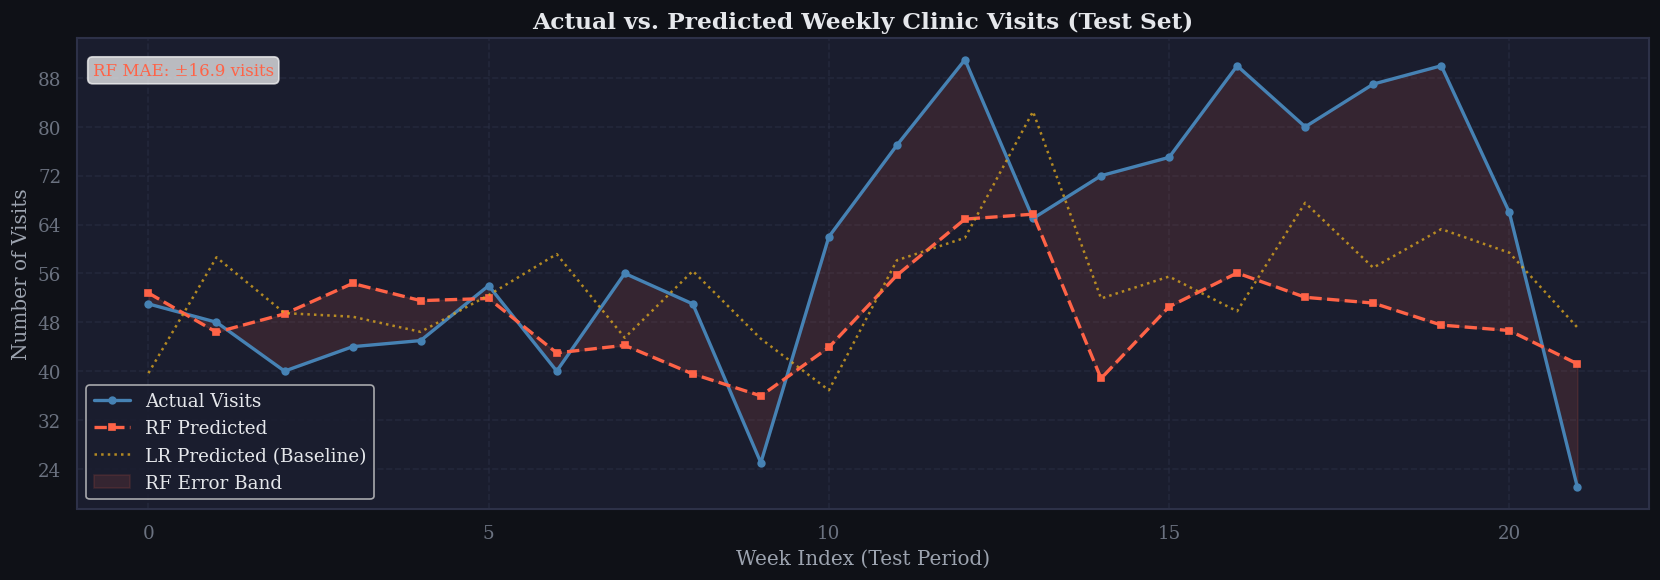

 Saved: models/actual_vs_predicted.png


In [8]:
test_weeks = weekly_model.iloc[split_idx:]['week'].values

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(range(len(y_test)), y_test.values,
        label='Actual Visits', color='steelblue', linewidth=2, marker='o', markersize=4)
ax.plot(range(len(y_pred_rf)), y_pred_rf,
        label='RF Predicted', color='tomato', linewidth=2, linestyle='--', marker='s', markersize=4)
ax.plot(range(len(y_pred_lr)), y_pred_lr,
        label='LR Predicted (Baseline)', color='goldenrod', linewidth=1.5,
        linestyle=':', alpha=0.8)

ax.fill_between(range(len(y_test)),
                y_test.values, y_pred_rf,
                alpha=0.12, color='tomato', label='RF Error Band')

ax.set_title('Actual vs. Predicted Weekly Clinic Visits (Test Set)', fontsize=14, fontweight='bold')
ax.set_xlabel('Week Index (Test Period)')
ax.set_ylabel('Number of Visits')
ax.legend()
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

mae_rf = mean_absolute_error(y_test, y_pred_rf)
ax.text(0.01, 0.95, f'RF MAE: ±{mae_rf:.1f} visits',
        transform=ax.transAxes, fontsize=10,
        verticalalignment='top', color='tomato',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.savefig('models/actual_vs_predicted.png', bbox_inches='tight')
plt.show()
print(' Saved: models/actual_vs_predicted.png')

### 8b. Feature Importance (Random Forest)

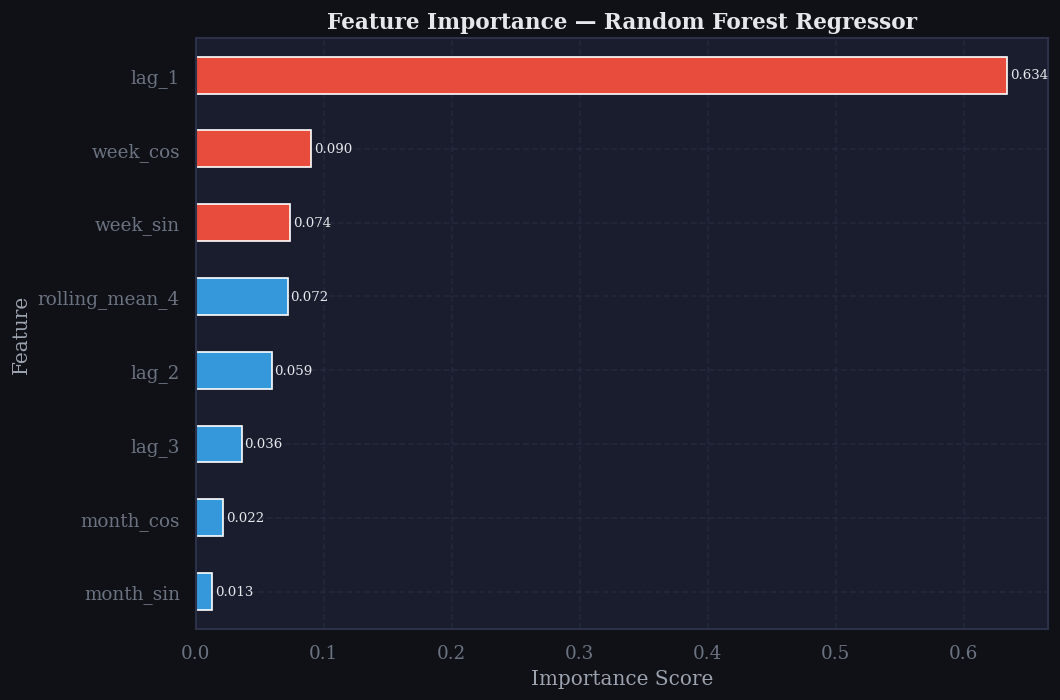

 Saved: models/feature_importance.png


In [9]:
importances = pd.Series(rf.feature_importances_, index=FEATURE_COLS)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#e74c3c' if i >= len(importances) - 3 else '#3498db'
          for i in range(len(importances))]
importances.plot(kind='barh', ax=ax, color=colors)

ax.set_title('Feature Importance — Random Forest Regressor', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.set_ylabel('Feature')

for i, (val, name) in enumerate(zip(importances, importances.index)):
    ax.text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('models/feature_importance.png', bbox_inches='tight')
plt.show()
print(' Saved: models/feature_importance.png')

### 8c. Model Comparison: MAE & RMSE Side-by-Side

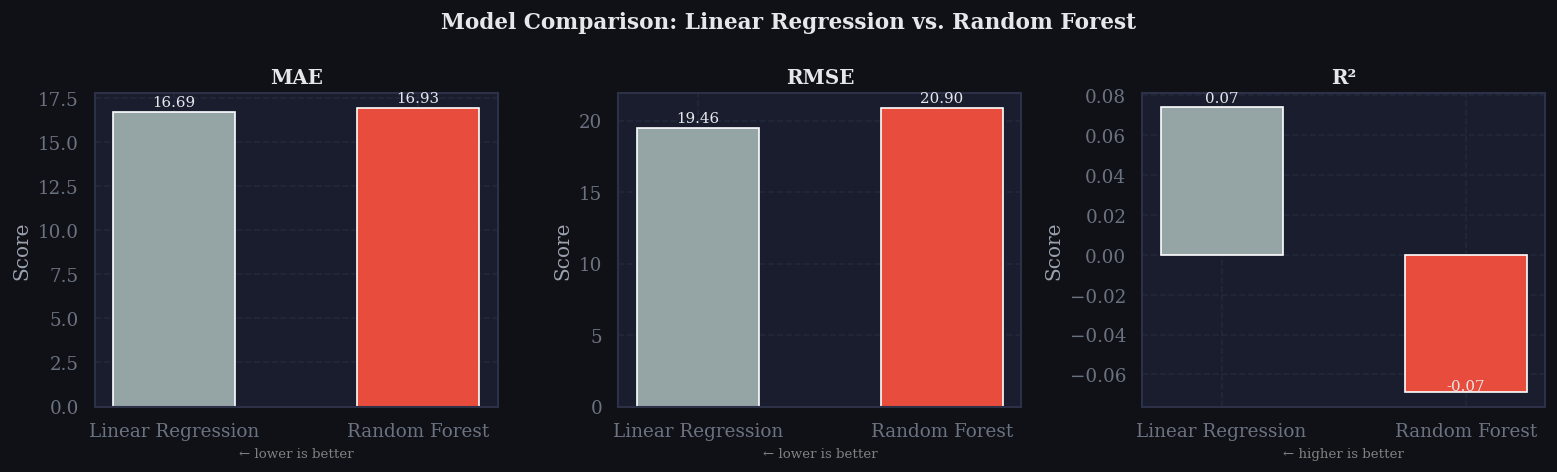

 Saved: models/model_comparison.png


In [10]:
metrics = {
    'Model'  : ['Linear Regression', 'Random Forest'],
    'MAE'    : [mean_absolute_error(y_test, y_pred_lr),
                mean_absolute_error(y_test, y_pred_rf)],
    'RMSE'   : [np.sqrt(mean_squared_error(y_test, y_pred_lr)),
                np.sqrt(mean_squared_error(y_test, y_pred_rf))],
    'R²'     : [r2_score(y_test, y_pred_lr),
                r2_score(y_test, y_pred_rf)],
}
metrics_df = pd.DataFrame(metrics)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
palette = ['#95a5a6', '#e74c3c']

for ax, metric, lower_better in zip(axes, ['MAE', 'RMSE', 'R²'], [True, True, False]):
    bars = ax.bar(metrics_df['Model'], metrics_df[metric], color=palette, edgecolor='white', width=0.5)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylabel('Score')
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01 * h,
                f'{h:.2f}', ha='center', va='bottom', fontsize=9)
    note = '← lower is better' if lower_better else '← higher is better'
    ax.set_xlabel(note, fontsize=8, color='gray')

fig.suptitle('Model Comparison: Linear Regression vs. Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('models/model_comparison.png', bbox_inches='tight')
plt.show()
print(' Saved: models/model_comparison.png')

### 8d. Risk-Tier Breakdown Forecast

This chart answers the operational question: *"Of next week's predicted visits, how many are from each risk tier?"*

  visits_academic_burnout_zone        → MAE: 8.00
  visits_food/water-borne_zone        → MAE: 5.84
  visits_high-acuity_/_malaria_risk   → MAE: 5.19


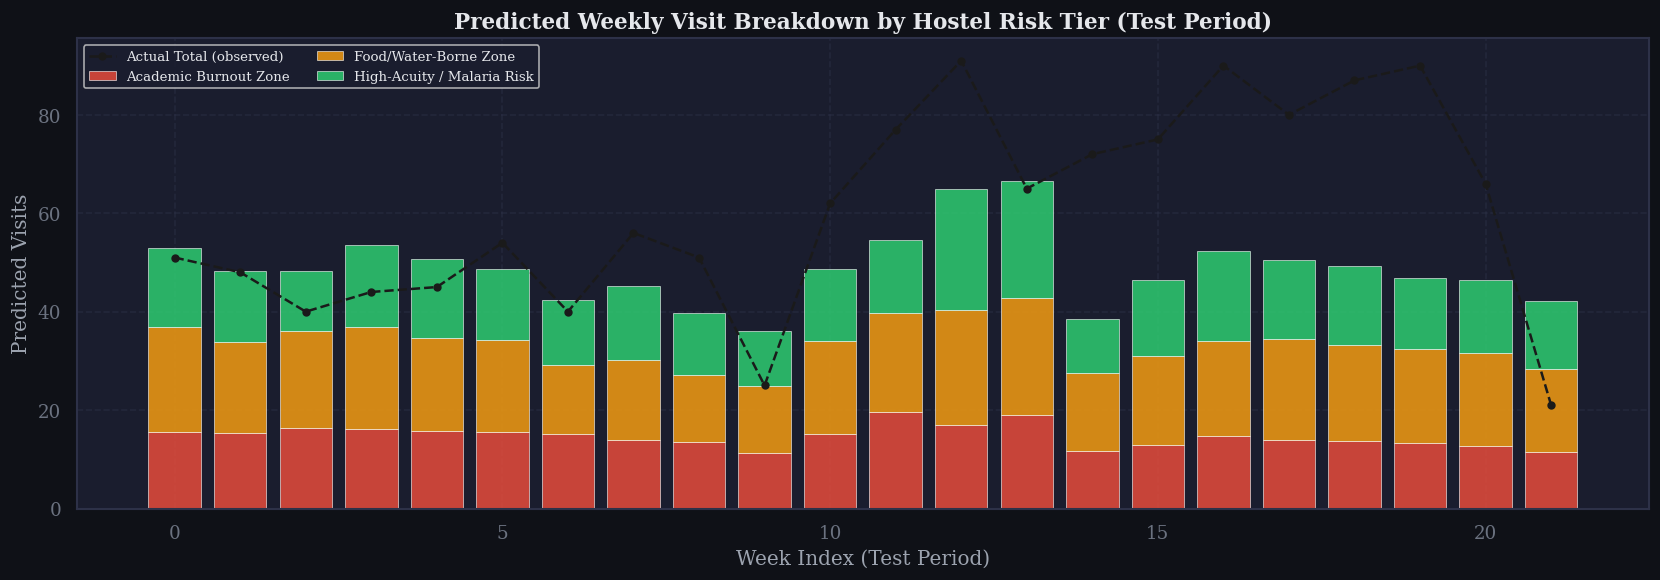

 Saved: models/tier_breakdown_forecast.png


In [11]:
# Train separate RF models for each risk tier
tier_predictions = {}
tier_actuals     = {}

for tcol in tier_visit_cols:
    y_tier        = weekly_model[tcol]
    y_tier_train  = y_tier.iloc[:split_idx]
    y_tier_test   = y_tier.iloc[split_idx:]

    rf_tier = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
    rf_tier.fit(X_train, y_tier_train)

    tier_predictions[tcol] = rf_tier.predict(X_test)
    tier_actuals[tcol]     = y_tier_test.values

    tier_mae = mean_absolute_error(y_tier_test, tier_predictions[tcol])
    print(f'  {tcol:35s} → MAE: {tier_mae:.2f}')

# === Stacked bar: predicted tier breakdown per test week ===
tier_labels = [c.replace('visits_', '').replace('_', ' ').title() for c in tier_visit_cols]
pred_matrix = np.array([tier_predictions[c] for c in tier_visit_cols])  # (n_tiers, n_weeks)

x_idx = np.arange(pred_matrix.shape[1])
colors_tiers = ['#e74c3c', '#f39c12', '#2ecc71', '#3498db', '#9b59b6']

fig, ax = plt.subplots(figsize=(14, 5))
bottom = np.zeros(pred_matrix.shape[1])

for i, (label, color) in enumerate(zip(tier_labels, colors_tiers)):
    ax.bar(x_idx, pred_matrix[i], bottom=bottom,
           label=label, color=color, alpha=0.85, edgecolor='white', linewidth=0.4)
    bottom += pred_matrix[i]

ax.plot(x_idx, y_test.values, 'ko--', linewidth=1.5, markersize=4,
        label='Actual Total (observed)', zorder=5)

ax.set_title('Predicted Weekly Visit Breakdown by Hostel Risk Tier (Test Period)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Week Index (Test Period)')
ax.set_ylabel('Predicted Visits')
ax.legend(loc='upper left', fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig('models/tier_breakdown_forecast.png', bbox_inches='tight')
plt.show()
print(' Saved: models/tier_breakdown_forecast.png')

## 9. Save Models

Saved models can be loaded directly by the Phase 5 Streamlit dashboard without retraining.

In [ ]:
joblib.dump(rf,     'models/rf_total_visits.pkl')
joblib.dump(lr,     'models/lr_total_visits.pkl')
joblib.dump(scaler, 'models/lr_scaler.pkl')

# Save feature column list for dashboard use
import json
with open('models/feature_cols.json', 'w') as f:
    json.dump(FEATURE_COLS, f)

print('    Models saved to /models/')
print('   - rf_total_visits.pkl   (primary model)')
print('   - lr_total_visits.pkl   (baseline model)')
print('   - lr_scaler.pkl         (scaler for LR)')
print('   - feature_cols.json     (feature list for dashboard)')

    Models saved to /models/
   - rf_total_visits.pkl   (primary model)
   - lr_total_visits.pkl   (baseline model)
   - lr_scaler.pkl         (scaler for LR)
   - feature_cols.json     (feature list for dashboard)


: 

## 10. Phase 4 Summary

| | Linear Regression | Random Forest |
|---|---|---|
| **Role** | Interpretable baseline | Primary predictor |
| **Scaling needed** | Yes (StandardScaler) | No |
| **Handles non-linearity** | ✗ | ✓ |
| **Key features** | Lag features, cyclical time | Same + tier breakdowns |
| **CV Folds** | — | 5-Fold (no shuffle) |

### What the dashboard (Phase 5) will consume:
- `rf_total_visits.pkl` — load and call `.predict()` on new week inputs
- `feature_cols.json` — ensure input arrays match training feature order
- `tier_breakdown_forecast.png` + `actual_vs_predicted.png` — embed directly as static charts

**Phase 4 is complete. Ready for Phase 5: Streamlit Dashboard.**